In [1]:
import os
import shutil
import random
import tqdm
import time
import torch
import torchaudio
import torchaudio.functional as ff
import torchaudio.transforms as tt
import matplotlib.pyplot as plt

In [2]:
ROOT_SRC = '/home/ovistetom/Documents/Databases_Local/WHAM/original'
ROOT_DST = '/home/ovistetom/Documents/Databases_Local/WHAM/preprocessed'
SAMPLE_RATE = 16000
os.makedirs(ROOT_DST, exist_ok=True)

___

In [3]:
def find_closest_multiple_of_ref(x, ref, round_up=False):
    return ref * ((x//ref)+round_up)

In [4]:
RESAMPLER = tt.Resample(orig_freq=48000, new_freq=SAMPLE_RATE)
FADER = tt.Fade(fade_in_len=16, fade_out_len=16)

In [5]:
MIN_DURATION_SIGNAL = 8
MIN_SAMPLES_SIGNAL = MIN_DURATION_SIGNAL * SAMPLE_RATE

In [6]:
for name_subset in ['trn', 'val', 'tst']:

    path_subset_src = os.path.join(ROOT_SRC, name_subset)
    path_subset_dst = os.path.join(ROOT_DST, name_subset)
    os.makedirs(path_subset_dst, exist_ok=True)

    for i_sample, name_sample in tqdm.tqdm(enumerate(os.listdir(path_subset_src)), total=len(os.listdir(path_subset_src)), desc=name_subset):

        path_sample_src = os.path.join(path_subset_src, name_sample)
        path_sample_dst = os.path.join(path_subset_dst, f"{name_sample}.flac")
        waveform, sr = torchaudio.load(uri=path_sample_src, normalize=True, channels_first=True)

        if waveform.size(0) > 1:
            waveform = waveform[0].unsqueeze(0)

        if waveform.mean() > 0.01:
            waveform = waveform - waveform.mean()

        if sr != SAMPLE_RATE:
            assert sr == 48000, f"Sample rate {sr} not supported."
            waveform = RESAMPLER(waveform)
        
        cut_index = find_closest_multiple_of_ref(x=waveform.size(1), ref=16, round_up=False)
        waveform = waveform[:cut_index]
        waveform = FADER(waveform)
        waveform = waveform / waveform.abs().max()

        if waveform.size(1) > MIN_SAMPLES_SIGNAL:
            torchaudio.save(uri=path_sample_dst, src=waveform, sample_rate=SAMPLE_RATE, channels_first=True)


tst: 100%|██████████| 3000/3000 [02:00<00:00, 24.95it/s]


___

## Analyse Dataset

In [7]:
ROOT_DB = os.path.join(ROOT_DST, 'trn')

list_waveform_length = []
list_waveform_power = []
#for speaker_name in os.listdir(ROOT_DB):
    #speaker_path = os.path.join(ROOT_DB, speaker_name)
for sample_name in os.listdir(ROOT_DB):
    sample_path = os.path.join(ROOT_DB, sample_name)
    waveform, sr = torchaudio.load(uri=sample_path, normalize=True, channels_first=True)
    waveform = waveform[0].unsqueeze(0)
    list_waveform_length.append(waveform.size(1) / sr)
    list_waveform_power.append((waveform.pow(2.0).sum() / waveform.size(1)).log().item())

print(f"Num. samples: {len(list_waveform_length)}")

Num. samples: 45729


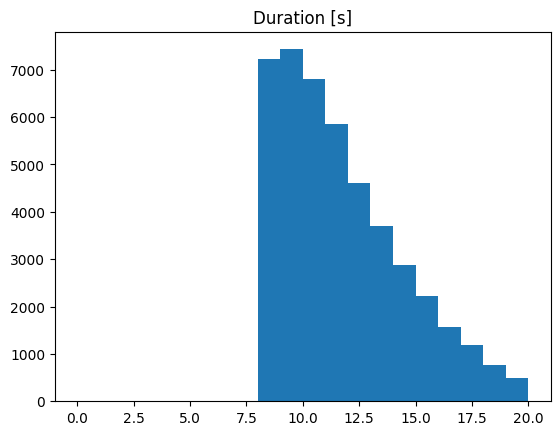

In [8]:
fig, axs = plt.subplots(1,1)
axs.hist(list_waveform_length, bins=20, range=(0.0, 20.0))
axs.set_title('Duration [s]')
plt.show()

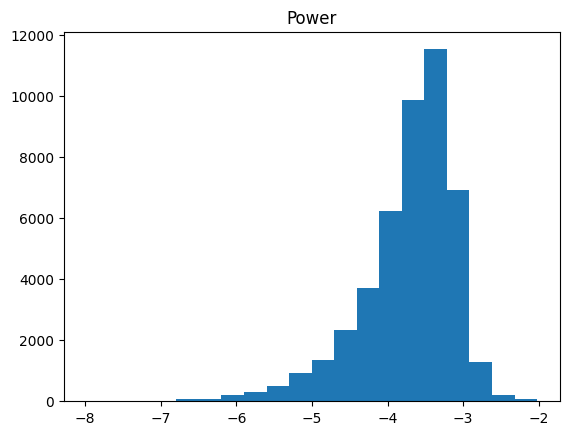

In [9]:
fig, axs = plt.subplots(1,1)
axs.hist(list_waveform_power, bins=20)
axs.set_title('Power')
plt.show()